## PhaseNet and EQT Picks Using Seisbench

In [1]:
import seisbench
import numpy as np
import torch
import obspy
import matplotlib.pyplot as plt


### Example

In [2]:
import seisbench.models as sbm

sbm.PhaseNet.list_pretrained()                  
model = sbm.PhaseNet.from_pretrained("geofon")  # Load the model trained on GEOFON

/opt/anaconda3/envs/ege-seisbench/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_

In [3]:
x = torch.rand(1, 3, 3001)  # 1 example, 3 components, 3001 samples
model.eval()
with torch.no_grad():
    print(model(x))

tensor([[[1.3491e-03, 1.9773e-03, 3.6720e-03,  ..., 3.3642e-03,
          3.7061e-03, 2.9827e-03],
         [3.5539e-05, 2.7684e-05, 4.0169e-05,  ..., 1.3565e-05,
          1.5851e-05, 7.2384e-05],
         [9.9862e-01, 9.9800e-01, 9.9629e-01,  ..., 9.9662e-01,
          9.9628e-01, 9.9694e-01]]])


## Stream Loading

In [4]:
!ls /home/ege//11NOV_2-3/

ls: cannot access '/home/ege//11NOV_2-3/': No such file or directory


In [5]:
stream = obspy.read('/home/ege/10NOV_2-3/SUSR_10NOV_2-3.mseed')
stream

6 Trace(s) in Stream:
KO.SUSR..EHE | 2025-11-13T01:49:55.740000Z - 2025-11-13T03:00:01.890000Z | 100.0 Hz, 420616 samples
KO.SUSR..EHN | 2025-11-13T01:49:54.120000Z - 2025-11-13T03:00:04.980000Z | 100.0 Hz, 421087 samples
KO.SUSR..EHZ | 2025-11-13T01:49:53.960000Z - 2025-11-13T03:00:05.980000Z | 100.0 Hz, 421203 samples
KO.SUSR..HNE | 2025-11-13T01:49:59.950000Z - 2025-11-13T03:00:04.360000Z | 100.0 Hz, 420442 samples
KO.SUSR..HNN | 2025-11-13T01:49:54.630000Z - 2025-11-13T03:00:06.620000Z | 100.0 Hz, 421200 samples
KO.SUSR..HNZ | 2025-11-13T01:49:53.850000Z - 2025-11-13T03:00:05.550000Z | 100.0 Hz, 421171 samples

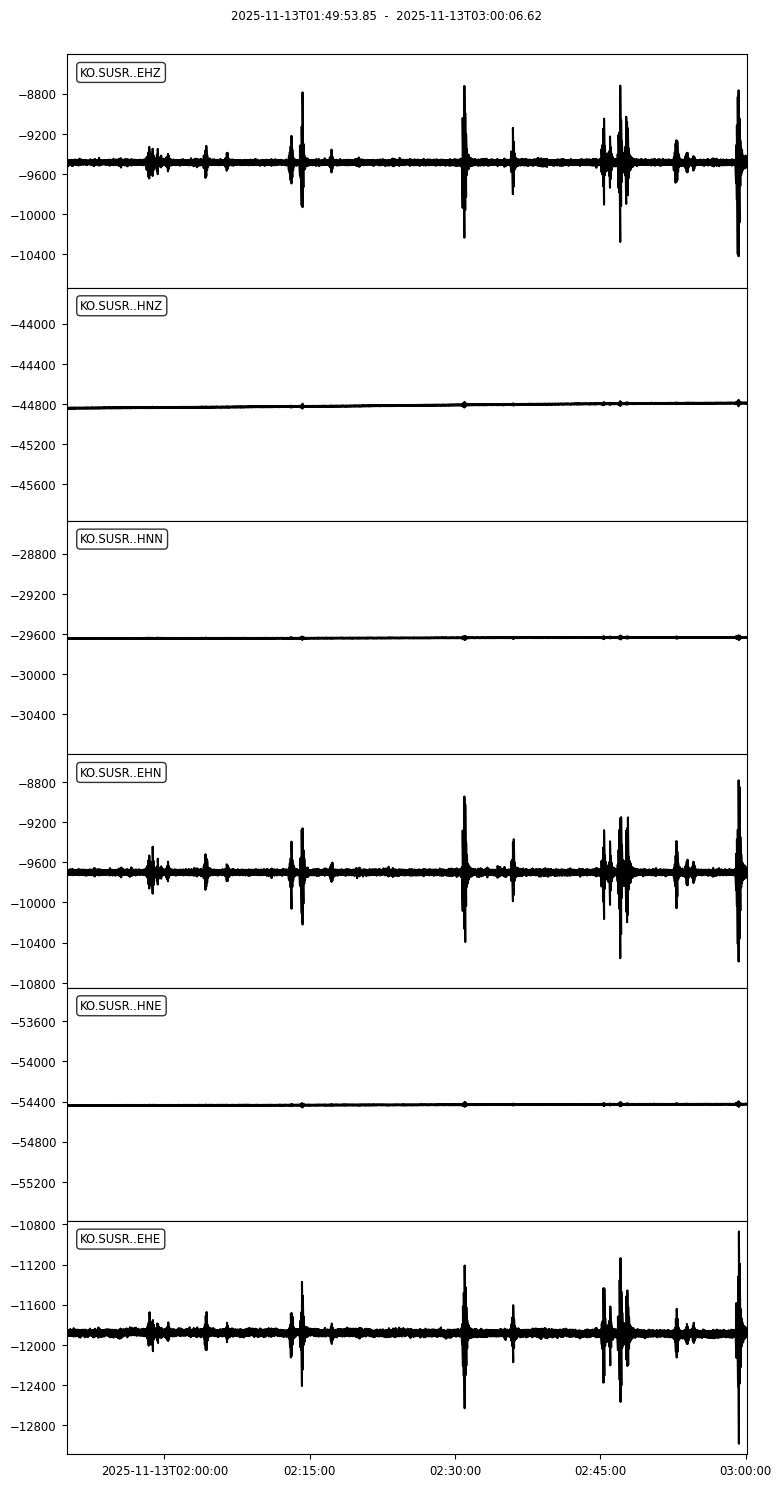

In [6]:
stream.plot();

In [7]:
for tr in stream:
    tr.detrend(type='constant')     
    tr.detrend(type='linear')
    tr.filter('bandpass', freqmin=1.0,freqmax=20.0)


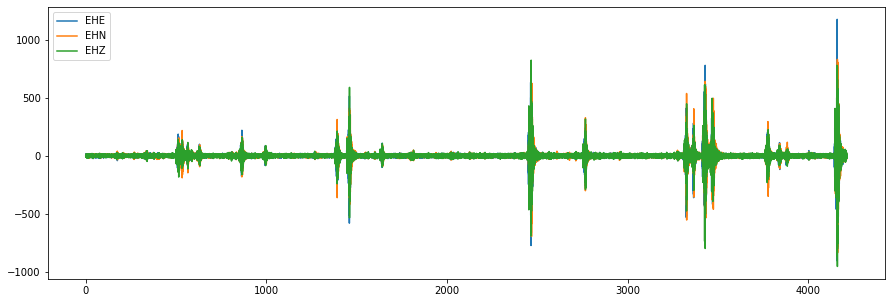

In [8]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(111)
for i in range(3):
    ax.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
ax.legend()

In [9]:
annotations = model.annotate(stream)
print(annotations)

6 Trace(s) in Stream:
KO.SUSR..PhaseNet_P | 2025-11-13T01:49:56.460000Z - 2025-11-13T03:00:03.480000Z | 100.0 Hz, 420703 samples
KO.SUSR..PhaseNet_S | 2025-11-13T01:49:56.460000Z - 2025-11-13T03:00:03.480000Z | 100.0 Hz, 420703 samples
KO.SUSR..PhaseNet_N | 2025-11-13T01:49:56.460000Z - 2025-11-13T03:00:03.480000Z | 100.0 Hz, 420703 samples
KO.SUSR..PhaseNet_P | 2025-11-13T01:49:56.350000Z - 2025-11-13T03:00:04.120000Z | 100.0 Hz, 420778 samples
KO.SUSR..PhaseNet_S | 2025-11-13T01:49:56.350000Z - 2025-11-13T03:00:04.120000Z | 100.0 Hz, 420778 samples
KO.SUSR..PhaseNet_N | 2025-11-13T01:49:56.350000Z - 2025-11-13T03:00:04.120000Z | 100.0 Hz, 420778 samples


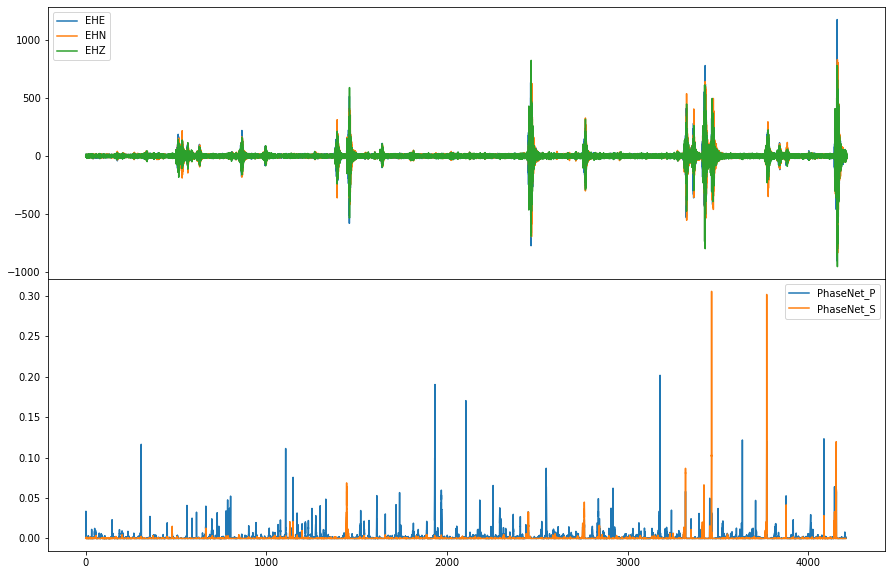

In [10]:
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()

## EQ Transformer With Stead

In [11]:
model = sbm.EQTransformer.from_pretrained("stead")
print(model.weights_docstring)

Model trained on STEAD for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)


/opt/anaconda3/envs/ege-seisbench/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_

6 Trace(s) in Stream:
KO.SUSR..EQTransformer_Detection | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_P         | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_S         | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_Detection | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples
KO.SUSR..EQTransformer_P         | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples
KO.SUSR..EQTransformer_S         | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples


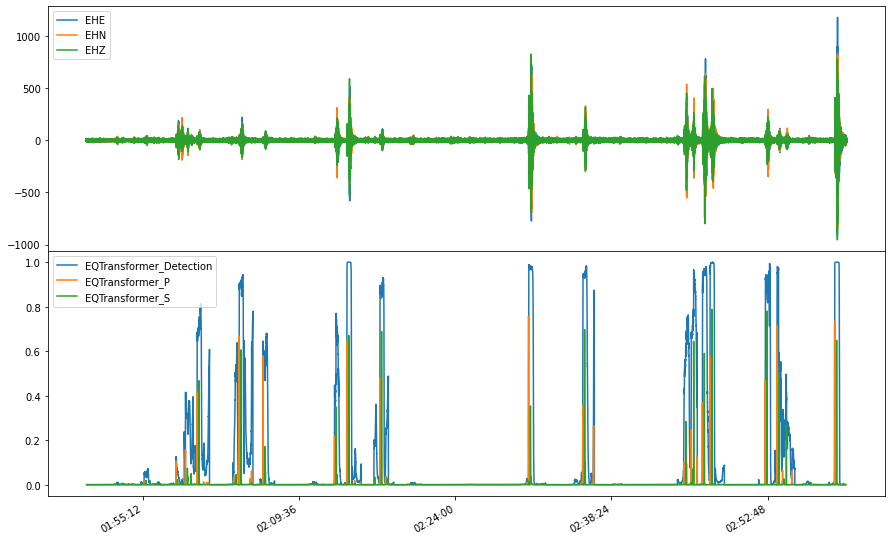

In [23]:
from matplotlib.dates import DateFormatter

annotations = model.annotate(stream)
print(annotations)
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})
offset = annotations[0].stats.starttime - stream[0].stats.starttime

for i in range(3):
    times = stream[i].times("matplotlib")
    axs[0].plot(times, stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":
        times = annotations[i].times("matplotlib") 
        axs[1].plot(times, annotations[i].data, label=annotations[i].stats.channel)

axs[0].legend()
axs[1].legend()
axs[1].xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
fig.autofmt_xdate()

6 Trace(s) in Stream:
KO.SUSR..EQTransformer_Detection | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_P         | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_S         | 2025-11-13T01:49:58.960000Z - 2025-11-13T03:00:00.980000Z | 100.0 Hz, 420203 samples
KO.SUSR..EQTransformer_Detection | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples
KO.SUSR..EQTransformer_P         | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples
KO.SUSR..EQTransformer_S         | 2025-11-13T01:49:58.850000Z - 2025-11-13T03:00:01.620000Z | 100.0 Hz, 420278 samples


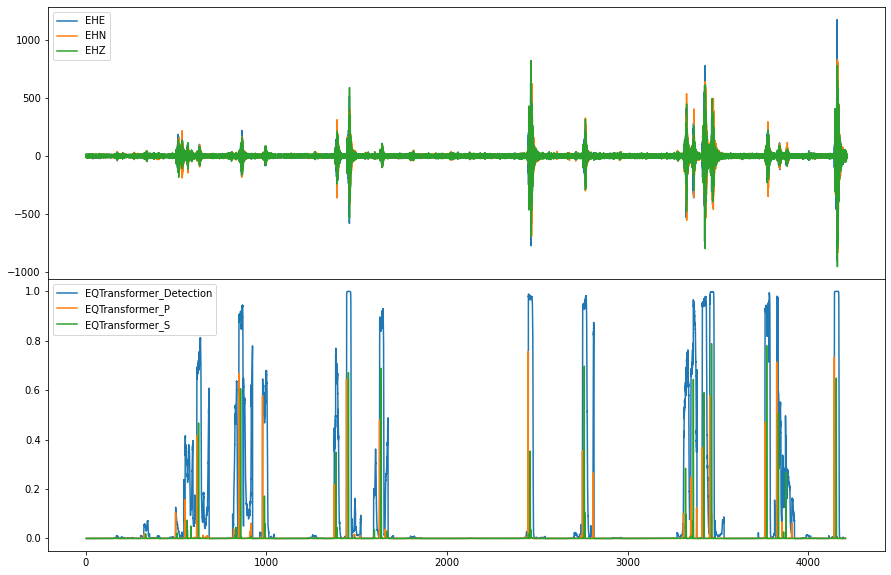

In [24]:
annotations = model.annotate(stream)
print(annotations)

fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):

    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()